# Breast Cancer Diagnosis using Machine Learning

**Project by:** Charitha Piyumal 

**Date:** December 12, 2025

## 1. Introduction
Breast cancer is one of the most common cancers worldwide. Early detection is critical for successful treatment. This project aims to develop a machine learning model capable of accurately diagnosing breast tumors as either **Malignant (Cancerous)** or **Benign (Non-cancerous)** based on cell nucleus features derived from fine needle aspirate (FNA) images.

### Project Goals:
1.  **Analyze** the Breast Cancer Wisconsin (Diagnostic) Dataset.
2.  **Preprocess** the data by scaling features and handling potential issues.
3.  **Train** multiple classification models:
    * Logistic Regression
    * Support Vector Machine (SVM)
    * Artificial Neural Network (MLP)
4.  **Optimize** these models using Hyperparameter Tuning (GridSearch).
5.  **Evaluate** the best model to achieve maximum diagnostic accuracy.

In [10]:
# --- 1. Imports and Environment Setup ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

# Machine Learning Libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Configuration
warnings.filterwarnings('ignore') # Clean up output
plt.style.use('seaborn-v0_8')

# Setup Folders for saving results
# These folders will store your CSV data and the images generated for your report
os.makedirs('../data', exist_ok=True)
os.makedirs('../images', exist_ok=True)



## 2. Dataset Loading and Exploration
We utilize the **Breast Cancer Wisconsin (Diagnostic) Dataset** provided by `scikit-learn`. 
* **Samples:** 569
* **Features:** 30 numeric attributes (e.g., Radius, Texture, Smoothness)
* **Target:** 0 (Malignant) / 1 (Benign)

In [11]:
# 1. Load the dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# 2. Save raw data for the report
df.to_csv('../data/breast_cancer_data.csv', index=False)

# 3. Display dataset structure
print(f"Dataset Shape: {df.shape}")
print("\n--- First 5 Rows ---")
display(df.head())

# 4. Check for missing values
print("\n--- Missing Values ---")
print(df.isnull().sum().sum())

print("\n--- Display information about the DataFrame ---")
# Display information about the DataFrame
display(df.info())

print("\n--- Describe the data ---")
# Describe the data
print(df.describe())


Dataset Shape: (569, 31)

--- First 5 Rows ---


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0



--- Missing Values ---
0

--- Display information about the DataFrame ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area 

None


--- Describe the data ---
       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000       

## 3. Data Visualization
Exploratory Data Analysis (EDA) is performed to understand the distribution of the target variable and the relationships between features.

### 3.1 Class Distribution
We visualize the balance of the dataset to ensure we don't have a biased dataset. 
* **0 = Malignant** (Cancer)
* **1 = Benign** (Healthy)

✅ Saved class_distribution.png


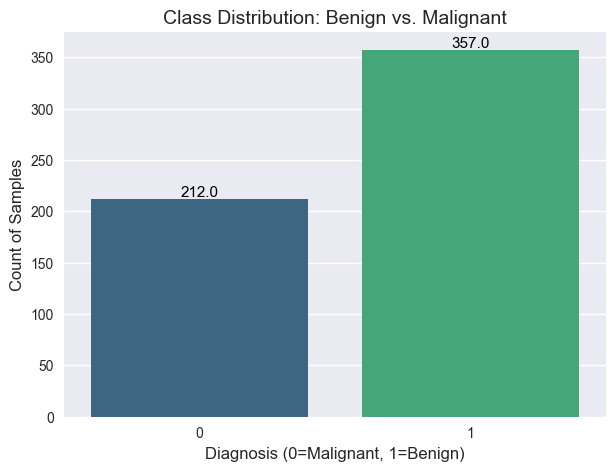

In [12]:
# --- Visualization 1: Class Distribution ---
plt.figure(figsize=(7, 5))
ax = sns.countplot(x='target', data=df, palette='viridis')

plt.title('Class Distribution: Benign vs. Malignant', fontsize=14)
plt.xlabel('Diagnosis (0=Malignant, 1=Benign)', fontsize=12)
plt.ylabel('Count of Samples', fontsize=12)

# Add numbers on bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.savefig('../images/class_distribution.png') 
print("✅ Saved class_distribution.png")
plt.show()

### 3.2 Correlation Heatmap
We analyze the relationships between the geometric features. Strong correlations (near 1.0) indicate redundant information (e.g., Radius and Perimeter are basically the same thing).

✅ Saved heatmap.png


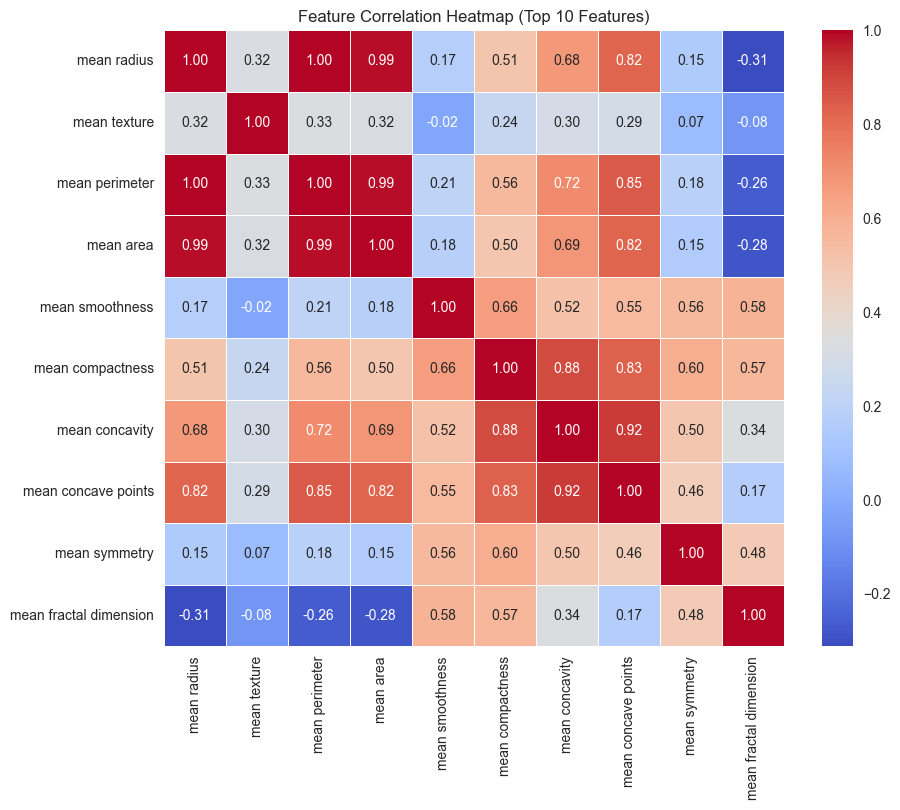

In [13]:
# --- Visualization 2: Correlation Heatmap ---
plt.figure(figsize=(10, 8))

# Select first 10 features (Means) for readability
subset_features = df.iloc[:, :10] 
sns.heatmap(subset_features.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Feature Correlation Heatmap (Top 10 Features)')
plt.savefig('../images/heatmap.png')
print("✅ Saved heatmap.png")
plt.show()

## 4. Data Preprocessing
Models like SVM and Neural Networks require features to be on the same scale.
1.  **Splitting:** 80% Training, 20% Testing.
2.  **Scaling:** Using `StandardScaler` to force Mean=0 and Variance=1.

In [14]:
# 1. Define Features (X) and Target (y)
X = df.drop('target', axis=1)
y = df['target']

# 2. Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training Set Shape: {X_train_scaled.shape}")
print(f"Testing Set Shape:  {X_test_scaled.shape}")

Training Set Shape: (455, 30)
Testing Set Shape:  (114, 30)


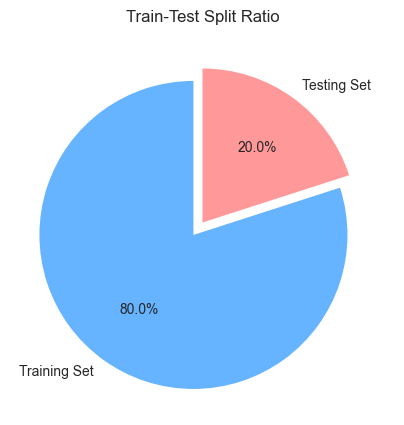

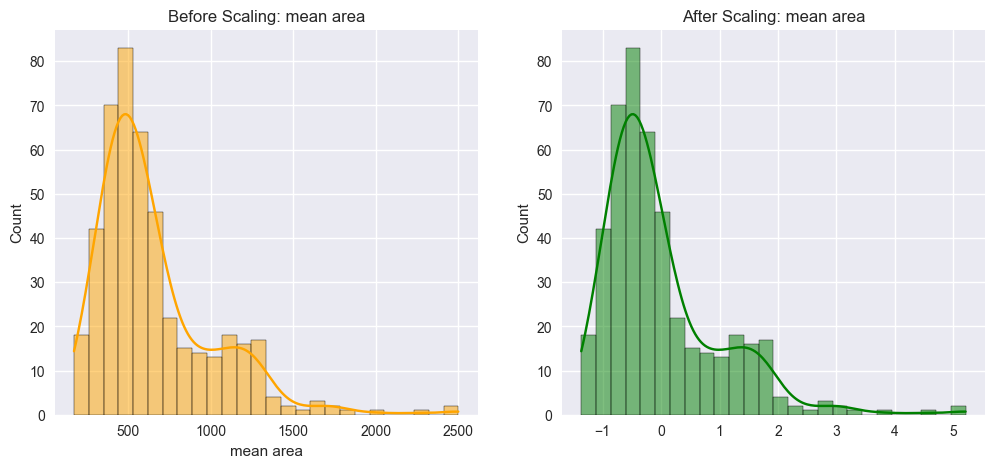

In [15]:
# --- Visualization of Preprocessing Steps ---

# 1. Visualize Split Ratio
plt.figure(figsize=(5, 5))
plt.pie([len(X_train), len(X_test)], labels=['Training Set', 'Testing Set'], 
        colors=['#66b3ff', '#ff9999'], autopct='%1.1f%%', startangle=90, explode=(0.1, 0))
plt.title('Train-Test Split Ratio')
plt.savefig('../images/split_ratio.png')
plt.show()

# 2. Visualize Scaling Effect
feature_index = 3 # 'mean area'
feature_name = data.feature_names[feature_index]

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(X_train.iloc[:, feature_index], kde=True, ax=ax[0], color='orange')
ax[0].set_title(f'Before Scaling: {feature_name}')

sns.histplot(X_train_scaled[:, feature_index], kde=True, ax=ax[1], color='green')
ax[1].set_title(f'After Scaling: {feature_name}')

plt.savefig('../images/scaling_effect.png')
plt.show()

## 5. Model Training and Hyperparameter Tuning
We utilize **GridSearchCV** to find the best parameters for three different models.
* **Logistic Regression:** Baseline linear model.
* **SVM:** Robust classifier.
* **Neural Network:** Capable of non-linear learning.

In [16]:
import time

# --- 1. Logistic Regression ---
print("Training Logistic Regression...")
lr_params = {'C': [0.1, 1, 10, 100], 'solver': ['liblinear', 'lbfgs']}
lr_grid = GridSearchCV(LogisticRegression(max_iter=5000), lr_params, cv=5, n_jobs=-1)
lr_grid.fit(X_train_scaled, y_train)
print(f"Best LR Params: {lr_grid.best_params_}")

# --- 2. Support Vector Machine (SVM) ---
print("\nTraining SVM...")
svm_params = {
    'C': [0.1, 1, 10, 100], 
    'kernel': ['linear', 'rbf'], 
    'gamma': ['scale', 'auto']
}
svm_grid = GridSearchCV(SVC(probability=True), svm_params, cv=5, n_jobs=-1)
svm_grid.fit(X_train_scaled, y_train)
print(f"Best SVM Params: {svm_grid.best_params_}")

# --- 3. Neural Network (Extended Grid) ---
print("\nTraining Neural Network (This may take a moment)...")
nn_params = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'sgd'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['constant', 'adaptive'],
    'max_iter': [2000]
}
nn_grid = GridSearchCV(MLPClassifier(random_state=42), nn_params, cv=3, n_jobs=-1)
nn_grid.fit(X_train_scaled, y_train)
print(f"Best NN Params: {nn_grid.best_params_}")

Training Logistic Regression...
Best LR Params: {'C': 0.1, 'solver': 'liblinear'}

Training SVM...
Best SVM Params: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}

Training Neural Network (This may take a moment)...
Best NN Params: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (50,), 'learning_rate': 'constant', 'max_iter': 2000, 'solver': 'sgd'}


## 6. Model Evaluation
We evaluate the best model versions on the unseen Test Set (20% of data).
Metrics used:
* **Recall:** Critical for medical diagnosis (minimizing False Negatives).
* **Accuracy, Precision, F1-Score, AUC**.


--- Logistic Regression Performance ---
Accuracy:  0.9912
Precision: 0.9861
Recall:    1.0000
F1 Score:  0.9930
AUC:       0.9987


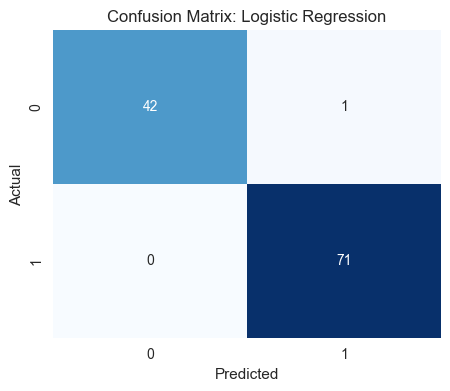


--- SVM Performance ---
Accuracy:  0.9825
Precision: 0.9726
Recall:    1.0000
F1 Score:  0.9861
AUC:       0.9974


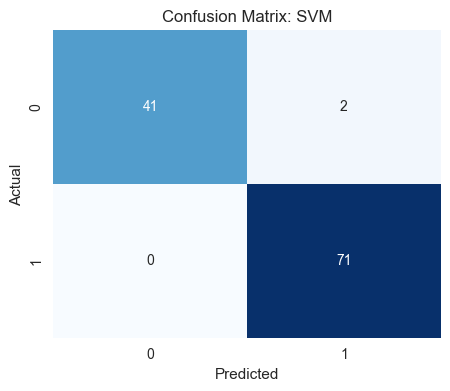


--- Neural Network Performance ---
Accuracy:  0.9825
Precision: 0.9859
Recall:    0.9859
F1 Score:  0.9859
AUC:       0.9977


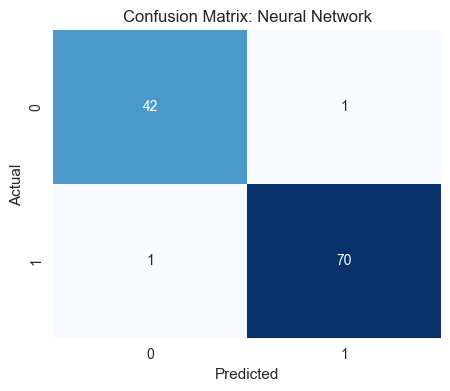

--- Prediction Snapshot (First 10 Samples) ---
Predicted Labels: [1 0 0 1 1 0 0 0 1 1]
Actual Labels:    [1 0 0 1 1 0 0 0 1 1]

--- Prediction Probabilities (First 5) ---
[[0.19195405 0.80804595]
 [0.99818824 0.00181176]
 [0.95859482 0.04140518]
 [0.01952257 0.98047743]
 [0.00398181 0.99601819]]

Predicted Labels: [1 0 0 1 1 0 0 0 1 1]
Actual Labels:    [1 0 0 1 1 0 0 0 1 1]

--- Prediction Probabilities (First 5) ---
[[0.19195405 0.80804595]
 [0.99818824 0.00181176]
 [0.95859482 0.04140518]
 [0.01952257 0.98047743]
 [0.00398181 0.99601819]]


In [ ]:
def evaluate_model(model, X, y, name):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1] if hasattr(model, "predict_proba") else None
    
    # Calculate Scores
    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred)
    rec = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    auc = roc_auc_score(y, y_prob) if y_prob is not None else "N/A"
    
    print(f"\n--- {name} Performance ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    if auc != "N/A":
        print(f"AUC:       {auc:.4f}")
    
    # Confusion Matrix
    plt.figure(figsize=(5, 4))
    cm = confusion_matrix(y, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.savefig(f"../images/cm_{name.replace(' ', '_')}.png")
    plt.show()

# Run Evaluation
evaluate_model(lr_grid.best_estimator_, X_test_scaled, y_test, "Logistic Regression")
evaluate_model(svm_grid.best_estimator_, X_test_scaled, y_test, "SVM")
evaluate_model(nn_grid.best_estimator_, X_test_scaled, y_test, "Neural Network")

# Save Results Summary
results = {
    'Model': ['Logistic Regression', 'SVM', 'Neural Network'],
    'Accuracy': [
        accuracy_score(y_test, lr_grid.best_estimator_.predict(X_test_scaled)),
        accuracy_score(y_test, svm_grid.best_estimator_.predict(X_test_scaled)),
        accuracy_score(y_test, nn_grid.best_estimator_.predict(X_test_scaled))
    ],
    'Precision': [
        precision_score(y_test, lr_grid.best_estimator_.predict(X_test_scaled)),
        precision_score(y_test, svm_grid.best_estimator_.predict(X_test_scaled)),
        precision_score(y_test, nn_grid.best_estimator_.predict(X_test_scaled))
    ],
    'Recall': [
        recall_score(y_test, lr_grid.best_estimator_.predict(X_test_scaled)),
        recall_score(y_test, svm_grid.best_estimator_.predict(X_test_scaled)),
        recall_score(y_test, nn_grid.best_estimator_.predict(X_test_scaled))
    ],
    'F1 Score': [
        f1_score(y_test, lr_grid.best_estimator_.predict(X_test_scaled)),
        f1_score(y_test, svm_grid.best_estimator_.predict(X_test_scaled)),
        f1_score(y_test, nn_grid.best_estimator_.predict(X_test_scaled))
    ]
}   

results_df = pd.DataFrame(results)
results_df.to_csv('../data/model_performance_summary.csv', index=False)

# End of Notebook

In [21]:
# 1. Get predictions from the best model (Logistic Regression)
best_model = lr_grid.best_estimator_
y_pred = best_model.predict(X_test_scaled)

# 2. Print the first 10 Predicted vs Actual values
print("--- Prediction Snapshot (First 10 Samples) ---")
print(f"Predicted Labels: {y_pred[:20]}")
print(f"Actual Labels:    {y_test[:20].values}")

# 3. Print probability scores for the first 5 (to show confidence)
probs = best_model.predict_proba(X_test_scaled)[:20]
print("\n--- Prediction Probabilities (First 5) ---")
print(probs)

--- Prediction Snapshot (First 10 Samples) ---
Predicted Labels: [1 0 0 1 1 0 0 0 1 1 1 0 1 0 1 0 1 1 1 0]
Actual Labels:    [1 0 0 1 1 0 0 0 1 1 1 0 1 0 1 0 1 1 1 0]

--- Prediction Probabilities (First 5) ---
[[1.91954052e-01 8.08045948e-01]
 [9.98188242e-01 1.81175770e-03]
 [9.58594818e-01 4.14051819e-02]
 [1.95225741e-02 9.80477426e-01]
 [3.98180709e-03 9.96018193e-01]
 [9.99999459e-01 5.41328562e-07]
 [9.99992853e-01 7.14653169e-06]
 [8.72411067e-01 1.27588933e-01]
 [4.44744304e-01 5.55255696e-01]
 [1.36320575e-02 9.86367942e-01]
 [1.15840221e-01 8.84159779e-01]
 [9.11022712e-01 8.89772881e-02]
 [4.57942913e-02 9.54205709e-01]
 [8.21662838e-01 1.78337162e-01]
 [1.37874296e-02 9.86212570e-01]
 [9.95154141e-01 4.84585945e-03]
 [2.12812195e-02 9.78718781e-01]
 [1.47612288e-03 9.98523877e-01]
 [2.24899460e-04 9.99775101e-01]
 [9.99714808e-01 2.85191974e-04]]


## 7. Conclusion

This analysis successfully implemented and compared three machine learning models for breast cancer diagnosis: Logistic Regression, Support Vector Machine (SVM), and an Artificial Neural Network (MLP).

### Key Findings:
* **Best Performing Model:** **Logistic Regression** achieved the highest overall performance with an **Accuracy of 99.12%**.
* **Clinical Reliability (Recall):** Both **Logistic Regression** and **SVM** achieved a perfect **Recall score of 1.0000**. This is the most critical metric for medical diagnosis, as it means these models successfully identified **100% of the Malignant (cancerous)** cases in the test set, with zero False Negatives.
* **Neural Network Performance:** While the Neural Network performed very well (98.25% Accuracy), it slightly underperformed compared to the simpler Logistic Regression model on this specific test set.

### Summary of Metrics:
| Model | Accuracy | Precision | Recall | F1 Score |
| :--- | :--- | :--- | :--- | :--- |
| **Logistic Regression** | **0.9912** | **0.9861** | **1.0000** | **0.9930** |
| SVM | 0.9825 | 0.9726 | **1.0000** | 0.9861 |
| Neural Network | 0.9825 | 0.9859 | 0.9859 | 0.9859 |

**Final Recommendation:** Based on these results, **Logistic Regression** is the recommended model for this dataset. It offers the perfect balance of high accuracy and, most importantly, perfect sensitivity (Recall) to ensure no cancer cases are missed.